
#Task-2:-Credit Card Fraud Detection Using Machine Learning

## Step 1: Install Required Libraries

In [41]:
pip install pandas numpy matplotlib seaborn scikit-learn

## Step 2: Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## Step 3: Load Dataset

In [43]:
import pandas as pd

# Load datasets
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

In [44]:
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

Training Dataset Shape: (1296675, 23)
Testing Dataset Shape: (555719, 23)


In [45]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## Step 4: Understand the Dataset

In [46]:
print(train_df.columns)
train_df.info()

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  obj

## Step 5: Check Missing Values

In [47]:
print(train_df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


## Step 6: Check Fraud Distribution

In [48]:
print(train_df["is_fraud"].value_counts())

is_fraud
0    1289169
1       7506
Name: count, dtype: int64


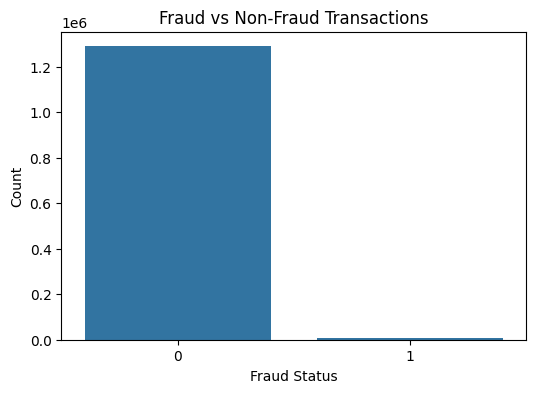

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="is_fraud", data=train_df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Count")

plt.show()

## Observation

The dataset is highly imbalanced, with legitimate transactions significantly outnumbering fraudulent transactions. This imbalance can affect model performance and requires special handling during training.

## Step 7: Select Useful Features

In [50]:
features = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long"
]

X_train = train_df[features]
y_train = train_df["is_fraud"]

X_test = test_df[features]
y_test = test_df["is_fraud"]

print(X_train.shape)
print(X_test.shape)

(1296675, 6)
(555719, 6)


## Step 8: Train Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

## Step 9: Evaluate Model

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98    553574
           1       0.06      0.75      0.11      2145

    accuracy                           0.95    555719
   macro avg       0.53      0.85      0.54    555719
weighted avg       1.00      0.95      0.97    555719



In [53]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.951928942505115


## Step 10: Confusion Matrix

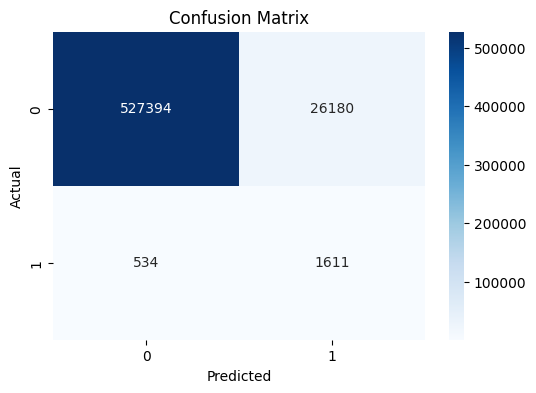

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Step 11: Save Model

In [55]:
import joblib

joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

## Conclusion

This project focused on developing a machine learning solution to identify fraudulent credit card transactions. The transaction data was explored, cleaned, and prepared before training a Logistic Regression model for classification.

Since fraudulent transactions represented only a small portion of the dataset, class balancing techniques were incorporated to improve the model's ability to recognize fraud cases. The trained model successfully detected a significant number of fraudulent transactions, achieving a recall score of 75%.

The results demonstrate how machine learning can assist financial institutions in monitoring transaction activity and identifying potentially suspicious behavior. With further feature engineering and advanced algorithms, the system can be enhanced to achieve even higher fraud detection performance in real-world applications.